# Prerequisite - Score Based Diffusion Model

Diffusion model is an effective tool to sample from a distribution $p(x)$, by starting from sampling from a template noise distribution, e.g. $\mathcal{N}(0, I)$, then denoise the noisy sample with a denoiser. To describe it more precisely, the template noise distribution is in fact a result of data distribution of a forward process of a stochastic differential equation:

$$
dx_t = f(t)x_t\,dt + g(t)\,dw_t
$$

where $x_0 \sim p_{\mathrm{data}}(x)$, scalar functions $f(t), g(t) : \mathbb{R} \to \mathbb{R}$ denote the **drift** and **diffusion coefficients**, respectively, and $\{w_t\}_{t \in [0,1]}$ is the standard Wiener process.

Thus, the sampling process is in fact a reverse process of the above SDE, using the following reverse-time ODE.

$$
dx_t = \left( f(t)x_t - \frac{1}{2} g^2(t)\nabla \log p_t(x_t) \right)\,dt.
$$

Unfortunately, the score function $\nabla_{x_t} \log p_t(x_t)$ at each $t \in [0,1]$ is typically unknown. We therefore estimate the posterior mean $\mathbb{E}[x_0 \mid x_t]$ as an alternative approach for estimating the score function, in which Tweedie's formula establishes an equivalence between the score function and posterior mean as follows:

$$
\mathbb{E}[\boldsymbol{x} \mid \boldsymbol{x}_t] = \frac{1}{\alpha_t}\left(\boldsymbol{x}_t + \sigma_t^2 \nabla \log p_t(\boldsymbol{x}_t)\right)
$$


# Conditional inference if we get ahold of the prior $p(x)$

Almost all application in machine learning can be viewed as a special case of the following inference problem. Given:
$$y = h(x) + w$$
where $h(\cdot)$ represents measurement of $x$ and $w$ represents some measurement noise and even sparse corruptions, solve the inverse problem of obtaining the most likely $x$ or sample $\hat{x}$ that is at least consistent with the observation. 



In this notebook, we care about the scenario which we only are provided paired data $(x,y)$.

By Bayes' rule and conditional independence of $y$ and $x_t$ given $x$, the optimal conditional denoiser can be written as

$$
\bar{\boldsymbol{x}}_\theta^{\text{CG, ideal}}(t, \boldsymbol{\xi}, \nu)
  = \mathbb{E}[\boldsymbol{x} \mid \boldsymbol{x}_t = \boldsymbol{\xi}]
  + \gamma \frac{\sigma_t^2}{\alpha_t}\,\nabla_{\boldsymbol{\xi}} \log p_{y \mid \boldsymbol{x}_t}(\nu \mid \boldsymbol{\xi})
$$


# Conditional inference with classifier free guidance

If we assume the classifier perfectly approximate the targets, we obtain the classifer free guidance denoiser:

$$
\bar{\boldsymbol{x}}_\theta^{\text{CFG}}(t, \boldsymbol{x}_t, y)
  = (1-\gamma)\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)
  + \gamma\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y)
$$

where $\gamma > 1$ which there is solid explannation of why large $\gamma > 1$ is essential but I am not documenting it here. 

## CFG denoiser for GMM

We will use the same network to represent both conditional and unconditional denoiser.

Given any distribution for $x$, there exists a Gaussian mixture that approximates it arbitrarily well. Here, let's consider the parameterization of denoiser for GMM.

$$
x \sim \frac{1}{K}\sum_{k=1}^{K} \mathcal{N}(0, U_k U_k^{\top})
$$

Recall:

$$
\bar{\boldsymbol{x}}_\theta^{\text{CFG}}(t, \boldsymbol{x}_t, y)
  = (1-\gamma)\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)
  + \gamma\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y)
$$

For GMM case, 

$$\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing) = \frac{1}{1+t^2}
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \frac{1}{2t^2(1+t^2)}\,
    \bigl\|U_k^\top \boldsymbol{x}_t\bigr\|_2^2
  \right)
}{
  \displaystyle
  \sum_{i=1}^{K}
  \exp\!\left(
    \frac{1}{2t^2(1+t^2)}\,
    \bigl\|U_i^\top \boldsymbol{x}_t\bigr\|_2^2
  \right)
}
\,U_k U_k^\top \boldsymbol{x}_t$$



$$\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) = \frac{1}{1+t^2} U_y U_y^\top \boldsymbol{x}_t$$

$$\bar{\boldsymbol{x}}^{\text{CFG, ideal}}(t, \boldsymbol{x}_t, y) = \frac{1}{1+t^2}\left( (1-\gamma)\sum_{k=1}^{K} \frac{\exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_k^\top \boldsymbol{x}_t\|_2^2\right)}{\sum_{i=1}^{K} \exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_i^\top \boldsymbol{x}_t\|_2^2\right)}\,\boldsymbol{U}_k\boldsymbol{U}_k^\top + \gamma\,\boldsymbol{U}_y\boldsymbol{U}_y^\top \right)\boldsymbol{x}_t$$

We are now going to come up with one single operator that can be used to represent both $\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)$ and $\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) $

Let's make some assumptions

Now we consider the problem of parameterizing a learnable denoiser $\boldsymbol{x}_\theta^{\text{CFG}}$ to represent the optimal denoiser. For tractability, we add an additional assumption associated to the subspaces $\boldsymbol{U}_k$ being ‘distinguishable’ from one another, which is natural in practice: specifically, we assume that for any pair of indices $k, k' \in [K]$ with $k \neq k'$, we can find a set of $K$ nonzero directions $\boldsymbol{v}_k \in \mathbb{R}^D$ such that
$$
\boldsymbol{U}_k \boldsymbol{U}_k^\top \boldsymbol{v}_k = \boldsymbol{v}_k,\quad
\boldsymbol{U}_{k'} \boldsymbol{U}_{k'}^\top \boldsymbol{v}_k = \boldsymbol{0},\quad
k' \neq k.
$$

These vectors $\boldsymbol{v}_k$ can be considered as embeddings of class label $y$. It also comes with a benefit to map $y$ into a space of same dimension as where $x_t$ lives in. We can then come up with a general operator to represent both $\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)$ and $\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) $:

$$
(x_t, \boldsymbol{v}) \mapsto
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_k U_k^\top \boldsymbol{v}\bigr|
  \right)
}{
  \displaystyle\sum_{i=1}^{K}
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_i U_i^\top \boldsymbol{v}\bigr|
  \right)
}
\,U_k U_k^\top x_t
$$

If you plug in $v = x_t$, you will get exactly the unconditional denoiser and plugging in $v = v_y$ you will get class-conditional denoiser for $y$.


Now, we need to parameterize the following:

1. $U_k$
2. Mapping (i.e. encoder) $y \mapsto v_y$

## Unconditional denoiser for GMM

### Device

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import math
import numpy as np

# -----------------------------
# Device (Apple Silicon friendly)
# -----------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


### Generate synthetic dataset

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from __future__ import annotations

import torch.nn as nn
import torch.nn.functional as F


# Reproducibility
rng = np.random.default_rng(0)

# 3 orthogonal 1D subspaces in R^3 (standard basis)
U = np.eye(3)  # columns are orthonormal directions e1,e2,e3

# Mixture settings
K = 3
N_per = 40
sigma = 1.0  # along-subspace std
eps = 0.03    # set to e.g. 0.03 if you want tiny off-subspace jitter for visibility

Xs, ys = [], []
for k in range(K):
    z = rng.normal(0.0, sigma, size=(N_per, 1))          # scalar coordinate
    x = z @ U[:, [k]].T                                   # x = z * u_k^T  -> (N_per, 3)
    if eps > 0:
        x = x + rng.normal(0.0, eps, size=x.shape)        # optional tiny noise
    Xs.append(x)
    ys.append(np.full(N_per, k, dtype=int))

X = np.vstack(Xs)   # (N, 3)
y = np.concatenate(ys)

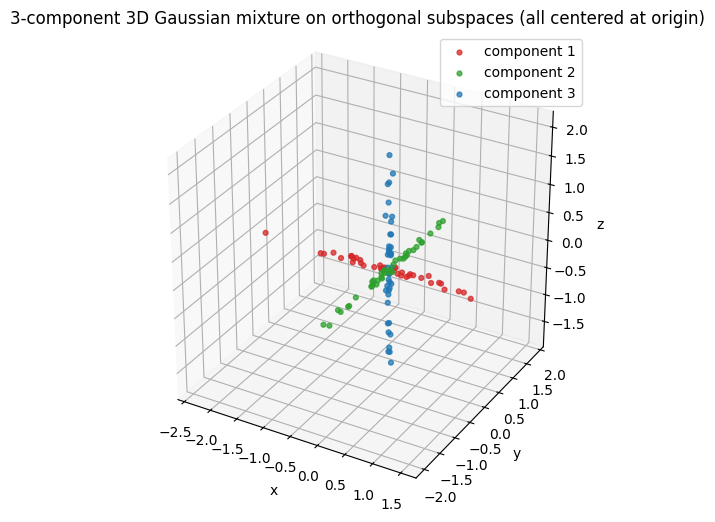

In [2]:
# Visualize (3D scatter, colored by component)
colors = ["tab:red", "tab:green", "tab:blue"]
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for k in range(K):
    pts = X[y == k]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, alpha=0.75, color=colors[k], label=f"component {k+1}")

ax.set_title("3-component 3D Gaussian mixture on orthogonal subspaces (all centered at origin)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
ax.set_box_aspect((1, 1, 1))
plt.show()

### Model architecture

Recall the model architecture is:

$$
(x_t, \boldsymbol{v}) \mapsto
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_k U_k^\top \boldsymbol{v}\bigr|
  \right)
}{
  \displaystyle\sum_{i=1}^{K}
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_i U_i^\top \boldsymbol{v}\bigr|
  \right)
}
\,U_k U_k^\top x_t
$$

It consist of 3 linear encoder and an embedding from $y$ to $v$

In [4]:
class WeightedEncoderNet(nn.Module):
    def __init__(
        self, 
        d: int, 
        K: int, 
        m: int
    ):
        super().__init__()
        self.d = d
        self.K = K
        self.m = m

        self.U = nn.Parameter(torch.empty(K, d, m))
        self.reset_parameters()

    def reset_parameters(self):
        # Initialize each encoder matrix U[k] independently
        for k in range(self.K):
            nn.init.xavier_uniform_(self.U[k])

    def forward(
        self, 
        x: torch.Tensor, 
        y: torch.Tensor,
        t: torch.Tensor | float
    ) -> torch.Tensor:
        emb_x = torch.einsum("bd,kdm->bkm", x, self.U)
        U_k_emb_x = torch.einsum("kdm,bkm->bkd", self.U, emb_x)
        emb_y = torch.einsum("bd,kdm->bkm", y, self.U)
        U_k_emb_y = torch.einsum("kdm,bkm->bkd", self.U, emb_y)

        norms = torch.einsum("bkd,bkd->bk", U_k_emb_x, U_k_emb_y)

        t = torch.as_tensor(t, dtype=x.dtype, device=x.device)
        # Optional safety for tiny t values:
        # t2 = t.pow(2).clamp_min(1e-8)
        # scale = 1.0 / (2.0 * (1.0 + t2) * t2)
        scale = 1.0 / (2.0 * (1.0 + t.pow(2)) * t.pow(2))

        logits = norms * scale
        weights = F.softmax(logits, dim=1)
        x_out = torch.einsum("bk,bkd->bd", weights, U_k_emb_x)
        return x_out

### Load dataset

In [5]:
# -----------------------------
# 2) Data from your synthetic GMM
# -----------------------------
# X is created in your previous cell as np.ndarray of shape (N, 3)
X_data = torch.tensor(X, dtype=torch.float32)  # (N, d)
N, d = X_data.shape
dataset = TensorDataset(X_data)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)

### Hyperparameter setting

In [6]:
### Hyperparameters
# -----------------------------
# 3) Hyperparameters
# -----------------------------
d = 3
K = 3
m = 1  # keep output same dim as x0

t_min = 1e-2
t_max = 1

num_epochs = 3000

In [7]:
# -----------------------------
# Model
# -----------------------------
model = WeightedEncoderNet(d=d, K=K, m=m).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

### Model training

In [8]:
def sample_t(batch_size, device, t_min=1e-2, t_max=2.0):
    # log-uniform in [t_min, t_max]
    u = torch.rand(batch_size, 1, device=device)
    return t_min * (t_max / t_min) ** u

model.train()
for epoch in range(1, num_epochs + 1):
    total_loss = 0.0
    total_n = 0

    for (x0,) in loader:
        x0 = x0.to(device)                           # (B,3)
        B = x0.shape[0]

        t = sample_t(B, device, t_min, t_max)       # (B,1)
        eps = torch.randn_like(x0)                   # (B,3)
        xt = x0 + t * eps                            # VE perturbation: x_t = x0 + t * z

        x0_hat = model(xt, xt, t)                        # predict posterior mean / denoised x0
        loss = ((x0_hat - x0) ** 2).sum(dim=1).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B
        total_n += B

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | loss = {total_loss / total_n:.6f}")

Epoch    1 | loss = 2.448420
Epoch  100 | loss = 1.052457
Epoch  200 | loss = 0.676754
Epoch  300 | loss = 0.618591
Epoch  400 | loss = 0.510715
Epoch  500 | loss = 0.441166
Epoch  600 | loss = 0.508198
Epoch  700 | loss = 0.433162
Epoch  800 | loss = 0.267643
Epoch  900 | loss = 0.302826
Epoch 1000 | loss = 0.257375
Epoch 1100 | loss = 0.221474
Epoch 1200 | loss = 0.173487
Epoch 1300 | loss = 0.205453
Epoch 1400 | loss = 0.213683
Epoch 1500 | loss = 0.192359
Epoch 1600 | loss = 0.160735
Epoch 1700 | loss = 0.154854
Epoch 1800 | loss = 0.111068
Epoch 1900 | loss = 0.122181
Epoch 2000 | loss = 0.124940
Epoch 2100 | loss = 0.103012
Epoch 2200 | loss = 0.142101
Epoch 2300 | loss = 0.119372
Epoch 2400 | loss = 0.123815
Epoch 2500 | loss = 0.129668
Epoch 2600 | loss = 0.133291
Epoch 2700 | loss = 0.115516
Epoch 2800 | loss = 0.115853
Epoch 2900 | loss = 0.121548
Epoch 3000 | loss = 0.083614


### Sampling with trained model

In [9]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_ddim(
    model,
    n_samples=1000,
    t_max=2.0,
    t_min=1e-2,
    n_steps=400,
    gamma = 1.5,
    y_guidance = None,
    device="cpu",
):
    """DDIM (eta=0) for VE path x_t = x0 + t * z, same as training. Unconditional: v = x_t."""
    model.eval()
    device = torch.device(device)

    x = t_max * torch.randn(n_samples, 3, device=device)
    if y_guidance is not None:
        y = torch.tensor(y_guidance).unsqueeze(0).repeat(n_samples, 1).to(device)
    else:
        y = x
    ts = torch.linspace(t_max, t_min, n_steps + 1, device=device)

    for i in range(n_steps):
        t_cur = ts[i].expand(n_samples, 1)
        t_next = ts[i + 1].expand(n_samples, 1)
        t_safe = t_cur.clamp_min(1e-8)

        if y_guidance is not None:
            x0_hat = (1-gamma) * model(x, x, t_cur) + gamma * model(x, y, t_cur)
        else:
            x0_hat = model(x, x, t_cur)
        eps = (x - x0_hat) / t_safe
        x = x0_hat + t_next * eps

    return x.cpu()

# generate samples
samples = sample_ddim(
    model,
    n_samples=2000,
    t_max=t_max,
    t_min=t_min,
    n_steps=500,
    gamma=0,
    device=device
).numpy()

### Visualization

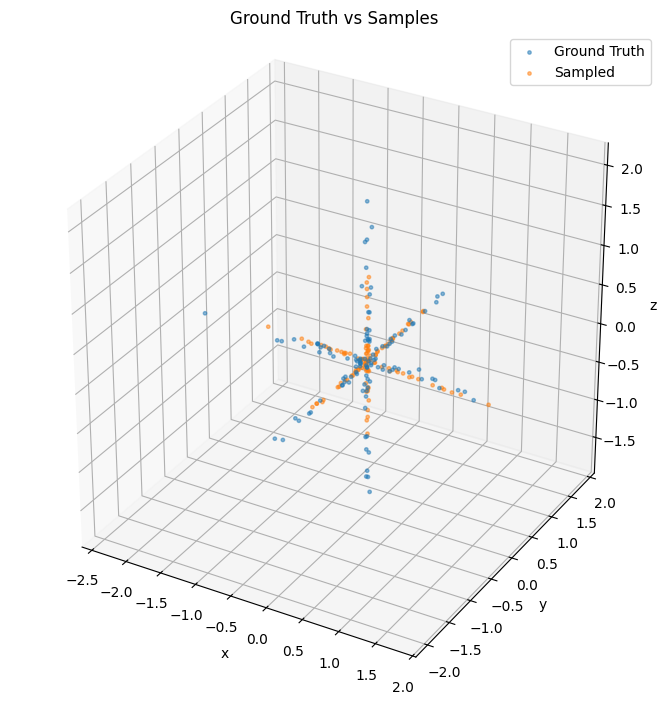

In [10]:
# gather ground truth dataset for comparison
# The ground truth data is assumed to be available as `loader`
# and the input data is in the first tensor of each batch (e.g., (x0,))
xs_gt = []
for (x0,) in loader:
    xs_gt.append(x0.cpu().numpy())
ground_truth = np.concatenate(xs_gt, axis=0)
# Optionally, subsample to match the number of samples, for fair visualization
if len(ground_truth) > len(samples):
    idx = np.random.choice(len(ground_truth), size=len(samples), replace=False)
    ground_truth = ground_truth[idx]
elif len(ground_truth) < len(samples):
    idx = np.random.choice(len(samples), size=len(ground_truth), replace=False)
    samples = samples[idx]

# visualize both distributions in the same 3D plot for direct comparison
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2],
    s=6, alpha=0.5, color="tab:blue", label="Ground Truth"
)
ax.scatter(
    samples[:, 0], samples[:, 1], samples[:, 2],
    s=6, alpha=0.5, color="tab:orange", label="Sampled"
)

ax.set_title("Ground Truth vs Samples")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.tight_layout()
plt.show()

# Conditional denoiser

$$\bar{\boldsymbol{x}}^{\text{CFG, ideal}}(t, \boldsymbol{x}_t, y) = \frac{1}{1+t^2}\left( (1-\gamma)\sum_{k=1}^{K} \frac{\exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_k^\top \boldsymbol{x}_t\|_2^2\right)}{\sum_{i=1}^{K} \exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_i^\top \boldsymbol{x}_t\|_2^2\right)}\,\boldsymbol{U}_k\boldsymbol{U}_k^\top + \gamma\,\boldsymbol{U}_y\boldsymbol{U}_y^\top \right)\boldsymbol{x}_t$$

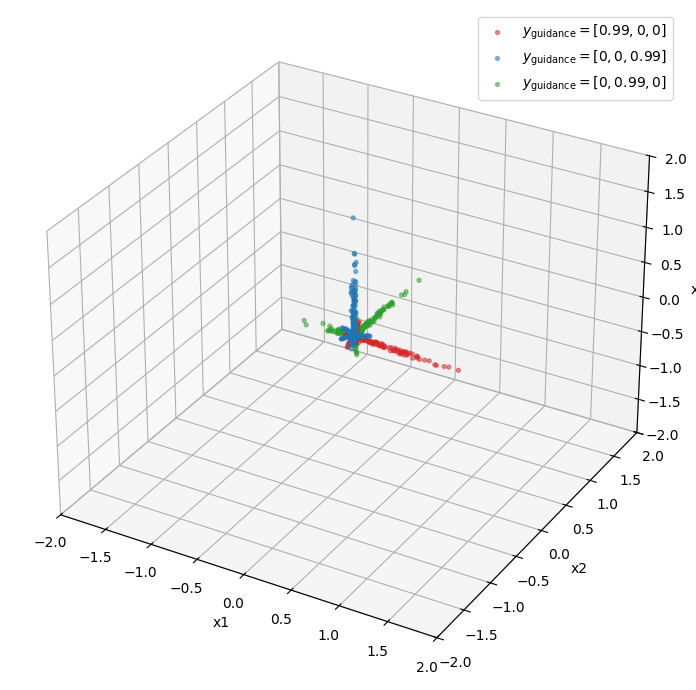

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

guidance_configs = [
    ([0.99, 0.0, 0.0], "tab:red",   r"$y_{\mathrm{guidance}}=[0.99,0,0]$"),
    ([0.0, 0.0, 0.99], "tab:blue",  r"$y_{\mathrm{guidance}}=[0,0,0.99]$"),
    ([0.0, 0.99, 0.0], "tab:green", r"$y_{\mathrm{guidance}}=[0,0.99,0]$"),
]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for y_g, color, label in guidance_configs:
    s = sample_ddim(
        model,
        n_samples=200,  # match what you use
        t_max=t_max,
        t_min=t_min,
        n_steps=500,
        gamma=1.5,       # use > 0 for CFG; tune as needed
        y_guidance=y_g,
        device=device,
    ).numpy()
    ax.scatter(s[:, 0], s[:, 1], s[:, 2], s=8, alpha=0.5, c=color, label=label)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.legend()
plt.tight_layout()
plt.show()

# Similarity between Multihead Cross Attention and Conditional Denoiser for GMM

The multihead cross attention looks like this:

$$
\begin{aligned}
\boldsymbol{Q} &= \boldsymbol{U}_{\boldsymbol{Q}}^{(i)} \varphi_{i}(\boldsymbol{z}_t), \\
\boldsymbol{K} &= \boldsymbol{U}_{\boldsymbol{K}}^{(i)} \tau_{\theta}(\boldsymbol{c}), \\
\boldsymbol{V} &= \boldsymbol{U}_{\boldsymbol{V}}^{(i)} \tau_{\theta}(\boldsymbol{c}),
\end{aligned}
$$

$$
\text{CrossAttn}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) \doteq \mathbf{V} \cdot \text{softmax} \left( \frac{\mathbf{K}^\top \mathbf{Q}}{\sqrt{d}} \right)
$$

$$
\begin{aligned}
\text{softmax}(\mathbf{A}) &\doteq \bigl[\text{softmax}(\mathbf{a}_1) \quad \cdots \quad \text{softmax}(\mathbf{a}_N)\bigr], \\
\forall \mathbf{A} &= [\mathbf{a}_1, \dots, \mathbf{a}_N] \in \mathbb{R}^{M \times N}.
\end{aligned}
$$

while conditional denoiser for GMM is in the form:

$$
(x_t, \boldsymbol{v}) \mapsto
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_k U_k^\top \boldsymbol{v}\bigr|
  \right)
}{
  \displaystyle\sum_{i=1}^{K}
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_i U_i^\top \boldsymbol{v}\bigr|
  \right)
}
\,U_k U_k^\top x_t
$$

We can see that the conditional denoiser for GMM bear a strong resemblance in the MHCA in the special case of one single query token.

The role of attention mechanism in both diffusion-denoising and autoregression are afterall, compression

## Iterative Denoising

$$
\hat{\mathbf{x}}_{t_{\ell-1}} = \left( 1 - \frac{1}{\ell} \right) \hat{\mathbf{x}}_{t_\ell} + \frac{1}{\ell} \, \bar{\mathbf{x}}^{\star}(t_\ell, \hat{\mathbf{x}}_{t_\ell}).
$$

where 

$$
\hat{\mathbf{x}}_{t_{\ell-1}} = \left( 1 - \frac{1}{\ell} \right) \hat{\mathbf{x}}_{t_\ell} + \frac{1}{\ell  (1+t^2)} 
\left[ \boldsymbol{U}_1, \dots, \boldsymbol{U}_K \right]
\begin{bmatrix}
\text{SSA}(\hat{\mathbf{x}}_{t_\ell}\mid \boldsymbol{U}_1) \\
\vdots \\
\text{SSA}(\hat{\mathbf{x}}_{t_\ell} \mid \boldsymbol{U}_K)
\end{bmatrix}

$$

where $\text{SSA}(\hat{\mathbf{x}}_{t_\ell} \mid \boldsymbol{U}_k)$ output a scalar how likely $\hat{\mathbf{x}}_{t_\ell}$ belong to subspace $U_k$

In addition, basically what cross attention is trying to do is to pick the right subspace guided by the signal embedding and through $\gamma$ in the CFG direct the denoising process towards to the desired class.

## Local Compression of tokens within a sample towards a mixture of subspace structure

$$
\mathbf{Z}^{\ell+1/2} = \left( 1 - \frac{\kappa p}{N\epsilon^2} \right) \mathbf{Z}^{\ell} + \frac{\kappa p}{N\epsilon^2} \, \text{MSSA}\bigl(\mathbf{Z}^{\ell} \mid \boldsymbol{U}_{[K]}^{\ell}\bigr)
$$

where

$$
\text{MSSA}(\boldsymbol{Z} \mid \boldsymbol{U}_{[K]}) \doteq \frac{p}{N \epsilon^2}
\left[ \boldsymbol{U}_1, \dots, \boldsymbol{U}_K \right]
\begin{bmatrix}
\text{SSA}(\boldsymbol{Z} \mid \boldsymbol{U}_1) \\
\vdots \\
\text{SSA}(\boldsymbol{Z} \mid \boldsymbol{U}_K)
\end{bmatrix}
$$


# Gaussian Mixture Model on FashionMNIST

Learnable parameters:

1. K diagonal matrices lambda_k that represent the singular values of truncated SVD of each class
2. K orthogonal bases U_k for each class
3. K means mu_k

# Interpretable RAE

In [ ]:
from typing import Callable
from typing import Sequence
from typing import Union

TensorLike = Union[
    torch.Tensor,
    float
]


class VariancePreservingProcess:
    """
    Variance-preserving process with:
      alpha(t) = sqrt(1 - t^2)
      sigma(t) = t

    Args:
        timesteps: sequence of time values (typically in [0, 1]).
        denoiser: callable with signature denoiser(x_t, t) -> predicted noise.
    """

    def __init__(
        self,
        timesteps: Sequence[float],
        denoiser: Callable
    ):
        if len(timesteps) == 0:
            raise ValueError("timesteps must be a non-empty sequence.")
        self.timesteps = torch.as_tensor(
            timesteps,
            dtype=torch.float32
        )
        self.denoiser = denoiser

    def alpha(
        self,
        t: TensorLike
    ) -> torch.Tensor:
        t = torch.as_tensor(
            t,
            dtype=torch.float32
        )
        # Clamp for numerical safety in sqrt
        return torch.sqrt(
            torch.clamp(
                1.0 - t**2,
                min=0.0
            )
        )

    def sigma(
        self,
        t: TensorLike
    ) -> torch.Tensor:
        return torch.as_tensor(
            t,
            dtype=torch.float32
        )

    def diffuse(
        self,
        x0: torch.Tensor,
        t: TensorLike,
        noise: torch.Tensor = None
    ) -> torch.Tensor:
        """
        Forward diffusion:
            x_t = alpha(t) * x0 + sigma(t) * eps
        """
        if noise is None:
            noise = torch.randn_like(x0)

        a = self.alpha(t).to(x0.device)
        s = self.sigma(t).to(x0.device)

        # Broadcast scalar t values across x0 shape
        while a.ndim < x0.ndim:
            a = a.unsqueeze(-1)
            s = s.unsqueeze(-1)

        return (
            a * x0 +
            s * noise
        )

    def denoise(
        self,
        x_t: torch.Tensor
    ) -> torch.Tensor:
        """
        Reverse denoising over stored timesteps using:
        x_{t_{l-1}} =
            (sigma_{l-1}/sigma_l) * x_{t_l}
            + (alpha_{l-1} - (sigma_{l-1}/sigma_l) * alpha_l) * x_star(t_l, x_{t_l})

        Assumes:
        - self.timesteps is ordered ascending (e.g., 0 -> 1)
        - input x_t is at the largest timestep (noisiest state)
        - self.denoiser(x, t) returns x_star(t, x), i.e. denoised estimate
        """
        if self.timesteps.numel() < 2:
            return x_t

        x = x_t
        ts = self.timesteps.to(device=x.device, dtype=x.dtype)

        # iterate: t_l -> t_{l-1}
        for l in range(ts.numel() - 1, 0, -1):
            t_l = ts[l]
            t_prev = ts[l - 1]

            x_star = self.denoiser(x, t_l)

            a_l = self.alpha(t_l).to(device=x.device, dtype=x.dtype)
            a_prev = self.alpha(t_prev).to(device=x.device, dtype=x.dtype)
            s_l = self.sigma(t_l).to(device=x.device, dtype=x.dtype)
            s_prev = self.sigma(t_prev).to(device=x.device, dtype=x.dtype)

            while a_l.ndim < x.ndim:
                a_l = a_l.unsqueeze(-1)
                a_prev = a_prev.unsqueeze(-1)
                s_l = s_l.unsqueeze(-1)
                s_prev = s_prev.unsqueeze(-1)

            ratio = s_prev / torch.clamp(s_l, min=1e-8)
            x = ratio * x + (a_prev - ratio * a_l) * x_star

        return x
        

x_flat shape: torch.Size([64, 784])


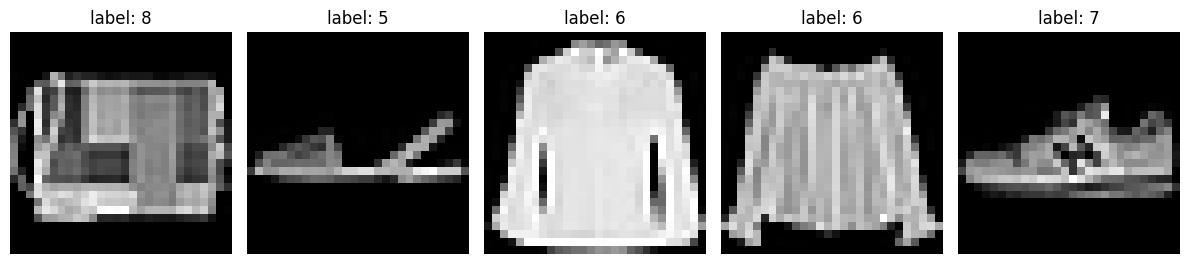

In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1) Dataset with ToTensor preprocessing
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,          # use training split only (no train/test split needed)
    download=True,
    transform=transform,
)

# 2) DataLoader
batch_size = 64
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# 3) Get first batch
x, y = next(iter(loader))     # x shape: [B, 1, 28, 28]

# 4) Flatten for downstream model: [B, d], where d = 28*28 = 784
x_flat = x.view(x.size(0), -1)   # [B, 784]
print("x_flat shape:", x_flat.shape)

# 5) Visualize first 5 samples from first batch
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(x[i, 0].cpu().numpy(), cmap="gray")
    axes[i].set_title(f"label: {y[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
ts = torch.linspace(0, 1, 100)
vp = VariancePreservingProcess(ts, lambda x, t: torch.randn_like(x))

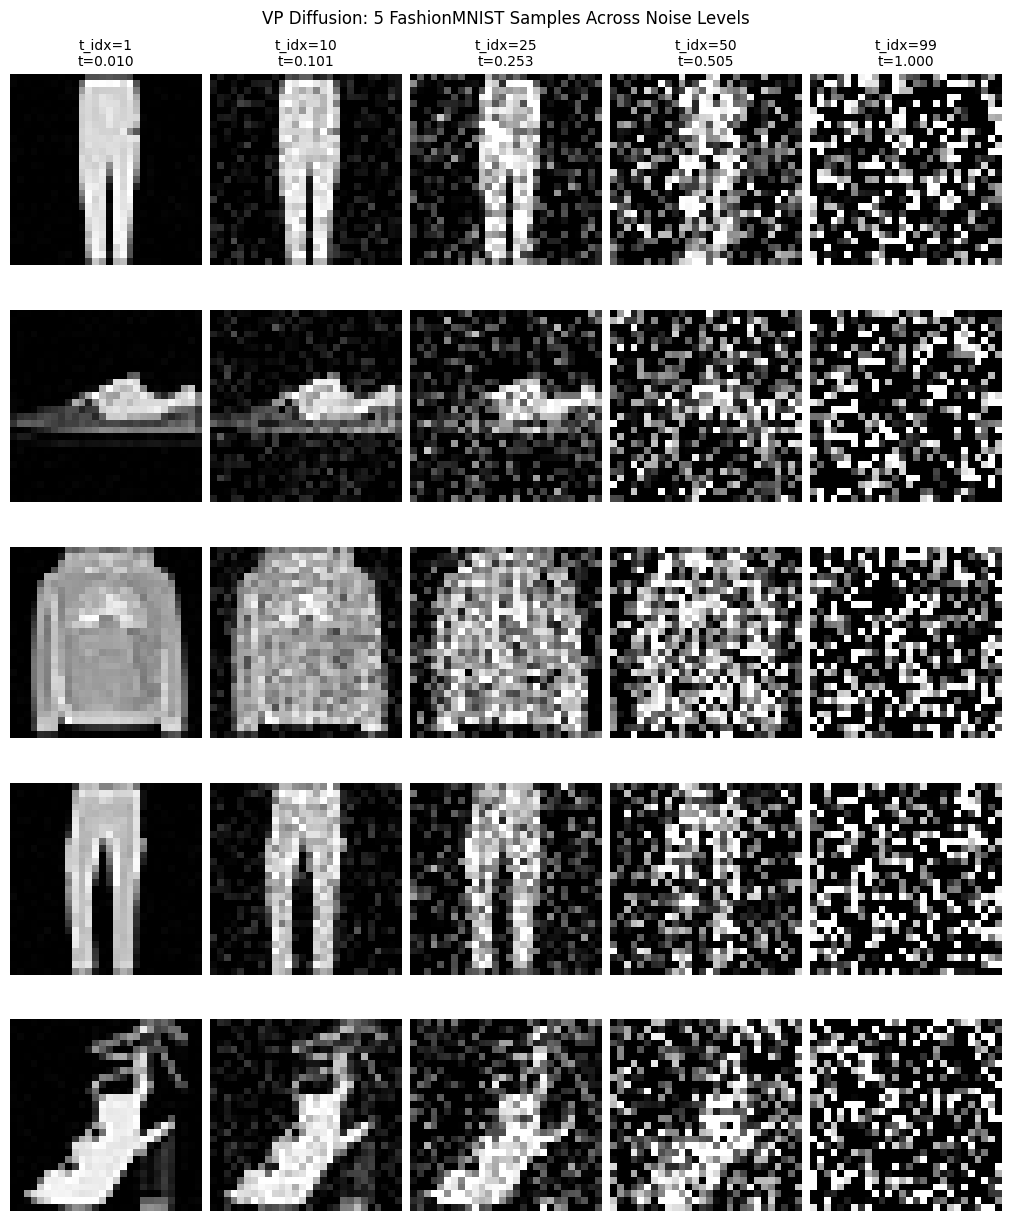

In [9]:
# Grab one batch and keep first 5 samples
x, _ = next(iter(loader))              # x: [B, 1, 28, 28]
x = x.view(x.size(0), -1)              # -> [B, 784]
x0 = x[:5]                              # first 5 samples

# Timesteps requested by you
# If your vp.timesteps is 0-indexed, use indices [25, 50, 75, 100].
# If you intended "25th/50th/..." elements (1-indexed), use [24, 49, 74, 99].
t_indices = [1, 10, 25, 50, 99]

# Convert indices -> actual t values used by vp.diffuse
t_values = [vp.timesteps[i] for i in t_indices]


num_samples = x0.shape[0]
num_timesteps = len(t_indices)

fig, axes = plt.subplots(
    nrows=num_samples, ncols=num_timesteps, figsize=(10, 12),
    constrained_layout=True
)

with torch.no_grad():
    for r in range(num_samples):  # rows: samples
        for c, t in enumerate(t_values):  # cols: noise levels
            xt = vp.diffuse(x0[r:r+1], t)            # [1, 784]
            img = xt.view(28, 28).cpu().numpy()      # FashionMNIST shape

            ax = axes[r, c]
            ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
            ax.axis("off")

            if r == 0:
                ax.set_title(f"t_idx={t_indices[c]}\nt={float(t):.3f}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"sample {r}", rotation=0, labelpad=28, va="center")

plt.suptitle("VP Diffusion: 5 FashionMNIST Samples Across Noise Levels", y=1.02)
plt.show()

# GMM Encoder using SVD

In [40]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

NUM_CLASSES = 10
K = NUM_CLASSES

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1)),
    ]
)

dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

def collate_flat_onehot(batch):
    images = torch.stack([b[0] for b in batch], dim=0)
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    y_onehot = F.one_hot(labels, num_classes=NUM_CLASSES).float()
    return images, y_onehot


loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_flat_onehot,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [41]:
# Compute per-class mean and truncated SVD (rank=20) of covariance on FashionMNIST\
RANK = 15
D = 28 * 28

# Collect all samples per class
class_samples = {k: [] for k in range(NUM_CLASSES)}

for images, y_onehot in loader:
    labels = y_onehot.argmax(dim=1)  # one-hot -> class index
    for k in range(NUM_CLASSES):
        mask = labels == k
        if mask.any():
            class_samples[k].append(images[mask])

# Compute mean and truncated SVD of covariance per class
class_stats = {}

for k in range(NUM_CLASSES):
    X = torch.cat(class_samples[k], dim=0)  # [N_k, 784]
    mean_k = X.mean(dim=0)                  # [784]

    Xc = X - mean_k
    cov_k = (Xc.T @ Xc) / (Xc.shape[0] - 1) # [784, 784]

    # Full SVD then truncate to top-20 components
    U, S, Vh = torch.linalg.svd(cov_k, full_matrices=False)

    class_stats[k] = {
        "mean": mean_k,          # [784]
        "singular_values": S[:RANK],     # [20]
        "U": U[:, :RANK],        # [784, 20]
        "Vh": Vh[:RANK, :],      # [20, 784]
    }

# Optional: stack all class means into [10, 784]
means_all = torch.stack([class_stats[k]["mean"] for k in range(NUM_CLASSES)], dim=0)

In [42]:
# mu: (K, D)   -> class means
mu = torch.stack([class_stats[k]["mean"] for k in range(K)], dim=0)

# U: (K, D, d) -> left singular vectors per class (top-d)
U = torch.stack([class_stats[k]["U"] for k in range(K)], dim=0)

# Sigma: (K, d) -> top-d singular values per class
D_diag = torch.stack([class_stats[k]["singular_values"] for k in range(K)], dim=0)

print("D_diag shape:", D_diag.shape)
print("mu shape:", mu.shape)  # (K, D)
print("U shape:", U.shape)    # (K, D, d)

D_diag shape: torch.Size([10, 15])
mu shape: torch.Size([10, 784])
U shape: torch.Size([10, 784, 15])


In [43]:
import functools
from typing import Callable, Sequence, Union

import torch

TensorLike = Union[torch.Tensor, float]


class VariancePreservingProcess:
    """
    Variance-preserving process with:
      alpha(t) = sqrt(1 - t^2)
      sigma(t) = t

    Args:
        timesteps: sequence of time values (typically in [0, 1]).
        denoiser: callable denoiser(x_t, a_l, s_l, y_onehot) -> x_star (posterior mean estimate).
    """

    def __init__(self, timesteps: Sequence[float], denoiser: Callable):
        if len(timesteps) == 0:
            raise ValueError("timesteps must be a non-empty sequence.")
        self.timesteps = torch.as_tensor(timesteps, dtype=torch.float32)
        self.denoiser = denoiser

    def alpha(self, t: TensorLike) -> torch.Tensor:
        t = torch.as_tensor(t, dtype=torch.float32)
        return torch.sqrt(torch.clamp(1.0 - t**2, min=0.0))

    def sigma(self, t: TensorLike) -> torch.Tensor:
        return torch.as_tensor(t, dtype=torch.float32)

    def diffuse(
        self,
        x0: torch.Tensor,
        t: TensorLike,
        noise: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """Forward diffusion: x_t = alpha(t) * x0 + sigma(t) * eps."""
        if noise is None:
            noise = torch.randn_like(x0)

        a = self.alpha(t).to(x0.device)
        s = self.sigma(t).to(x0.device)

        while a.ndim < x0.ndim:
            a = a.unsqueeze(-1)
            s = s.unsqueeze(-1)

        return a * x0 + s * noise

    def denoise(self, x_t: torch.Tensor, y_onehot: torch.Tensor) -> torch.Tensor:
        """
        Reverse denoising over stored timesteps.

        Assumes:
        - self.timesteps is ordered ascending (e.g. 0 -> 1)
        - input x_t is at the largest timestep (noisiest state)
        - self.denoiser(x, a_l, s_l, y_onehot) returns x_star at time t_l
        """
        if self.timesteps.numel() < 2:
            return x_t

        x = x_t
        ts = self.timesteps.to(device=x.device, dtype=x.dtype)

        for l in range(ts.numel() - 1, 0, -1):
            t_l = ts[l]
            t_prev = ts[l - 1]

            a_l = self.alpha(t_l).to(device=x.device, dtype=x.dtype)
            a_prev = self.alpha(t_prev).to(device=x.device, dtype=x.dtype)
            s_l = self.sigma(t_l).to(device=x.device, dtype=x.dtype)
            s_prev = self.sigma(t_prev).to(device=x.device, dtype=x.dtype)

            x_star = self.denoiser(x, a_l, s_l, y_onehot)

            while a_l.ndim < x.ndim:
                a_l = a_l.unsqueeze(-1)
                a_prev = a_prev.unsqueeze(-1)
                s_l = s_l.unsqueeze(-1)
                s_prev = s_prev.unsqueeze(-1)

            ratio = s_prev / torch.clamp(s_l, min=1e-8)
            x = ratio * x + (a_prev - ratio * a_l) * x_star

        return x


def gmm_denoiser(
    x_t: torch.Tensor,
    a_l: torch.Tensor,
    s_l: torch.Tensor,
    y_onehot: torch.Tensor,
    D_diag: torch.Tensor,
    U: torch.Tensor,
    mu: torch.Tensor,
) -> torch.Tensor:
    s2 = a_l * a_l
    g2 = s_l * s_l

    x_t_div_s = x_t / s_l
    v = x_t_div_s.unsqueeze(1) - mu
    z = torch.einsum("kdm, bkd -> bkm", U, v)

    log_lambda_D = s2 * D_diag / (g2 + s2 * D_diag)
    D_mat = torch.diag_embed(log_lambda_D)

    z = torch.einsum("kmn, bkn -> bkm", D_mat, z)
    z = torch.einsum("kdm, bkm -> bkd", U, z)
    z = mu + z

    y_onehot = y_onehot.unsqueeze(0)
    output_k = torch.einsum("bk, bkd -> bd", y_onehot, z)

    return output_k



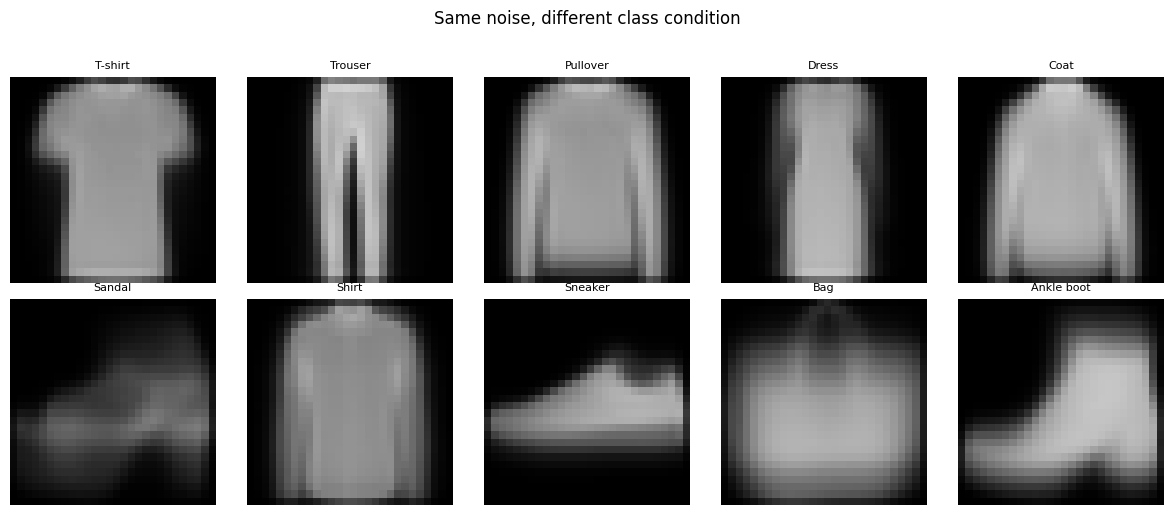

In [46]:
import matplotlib.pyplot as plt
import torch
import functools


class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

x_noisy = torch.randn(1, 784)
ts = torch.linspace(0.0, 1.0, steps=2)
vp = VariancePreservingProcess(
    ts,
    functools.partial(gmm_denoiser, D_diag=D_diag, U=U, mu=mu),
)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for c in range(10):
    y_onehot = torch.zeros(10, dtype=torch.float32)
    y_onehot[c] = 1.0
    x_hat = vp.denoise(x_noisy, y_onehot)

    x = x_hat.detach().cpu()
    if x.dim() == 2:
        x = x[0]
    img = x.view(28, 28).numpy()

    axes[c].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[c].set_title(class_names[c], fontsize=8)
    axes[c].axis("off")

plt.suptitle("Same noise, different class condition", y=1.02)
plt.tight_layout()
plt.show()

# To explore questions

1. When do diffusion models reproduce training data and when are they able to generate samples beyond it?
2. How to model causality?
3. What are the differences between cross attention and adding condition embedding to the timestep embedding?
4. Study the implementation of action conditioned world model